# EDA. Exploratory Data Analisy
Understanding the Data: Familiarize yourself with the dataset. Understand what variables you have, their types (numerical, categorical), and the context of the problem you're analyzing.

Data Cleaning: Identify and handle missing values, duplicates, and outliers. Data cleaning is essential to ensure the quality of the analysis.

Data Visualization: Use charts like histograms, scatter plots, box plots, etc., to visualize the distribution of variables and the relationships between them. This will help you identify patterns and anomalies.

Descriptive Statistics: Calculate basic statistical measures such as mean, median, standard deviation, percentiles, etc. These statistics will give you an overview of the data's characteristics.

Data Transformation: Consider transforming variables if necessary. For example, you can normalize or standardize data, or convert categorical variables into numerical ones using techniques like one-hot encoding.

Dimensionality Reduction: If you have a dataset with many variables, techniques like Principal Component Analysis (PCA) can help you reduce dimensionality without losing key information.

Iteration and Continuous Exploration: EDA is an iterative process. As you discover new insights, you may need to re-explore the data from different angles

# About the Dataset
source: https://www.kaggle.com/datasets/ashaychoudhary/indian-marriage-and-divorce-dataset.

This dataset contains marriages in India, capturing various socio-economic and demographic factors that may contribute to marital stability or divorce. It includes details such as age at marriage, type of marriage (arranged/love), education levels, income, caste/religion, family involvement, urban vs. rural living, number of children, and whether the marriage ended in divorce.

This dataset can be useful for sociologists, policymakers, and data scientists to analyze trends, identify risk factors, and develop insights into marriage patterns in India.
Marriage Duration (Years) – How long the marriage lasted (if divorced).
## About variables
- Age at Marriage – Age of the individuals when they got married.

- Arranged or Love Marriage – Type of marriage (Arranged, Love):

Arranged Marriage: This is a type of marriage where the partners are selected by their families, typically parents, rather than by the individuals themselves. In many cultures, arranged marriages are common and are seen as a way to ensure compatibility and stability1.

Love Marriage: This refers to a marriage where the partners choose each other based on mutual affection and love. The decision to marry is made by the individuals themselves, often after a period of dating or courtship

- Education Level – Highest education of both partners (No Education, Primary, Secondary, Graduate, Postgraduate).

- Income Level (INR per month) – Household income.

- Caste or Religion – Hindu, Muslim, Sikh, Christian, Jain, etc.

- Urban or Rural – Whether the couple lived in an urban or rural area.

- Family Involvement – Level of family involvement (Low, Moderate, High).

- Children – Number of children.

- Divorce Status – Whether the marriage led to a divorce (Yes, No)

## Interesting question about dataset
¿Can we find any relation beetwen the following variables?

1) Age at marriage and Marriage duration.
3) Age at marriage and Family Involvement.
3) Caste/Religion and Marriage Type.
4) Family Involvement and Children.
5) Urban/Rural and Children.
## Objetive
What are the aspects that have a significant influence on marriage duration, and how can we predict different factors in these types of marriages?

# Load and cleaning the Data

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("marriage_divorce_india_with_id.csv")

#Chaging currency type; INR to USD
df["Income Level (INR per month)"] = df["Income Level (INR per month)"] * 0.012
#Renaming column related to Income level
df.rename(columns={"Income Level (INR per month)":"Income Level (USD per month)"}, inplace=True)

df

,Unique ID,Marriage Duration (Years),Age at Marriage,Marriage Type,Education Level,Income Level (USD per month),Caste/Religion,Urban/Rural,Family Involvement,Children,Divorce Status
0,MD1,39,29,Love,Secondary,1361.568,Hindu,Rural,Moderate,2,No
1,MD2,29,34,Arranged,No Education,224.184,Jain,Rural,Moderate,0,Yes
2,MD3,15,34,Love,No Education,1913.460,Muslim,Urban,Moderate,4,Yes
3,MD4,8,27,Arranged,Postgraduate,757.920,Jain,Urban,High,1,Yes
4,MD5,21,34,Love,Secondary,343.992,Jain,Urban,High,1,Yes
...,...,...,...,...,...,...,...,...,...,...,...
1195,MD1196,38,22,Love,Primary,319.656,Muslim,Urban,High,4,No
1196,MD1197,34,21,Arranged,Postgraduate,72.876,Hindu,Rural,Moderate,2,No
1197,MD1198,12,23,Arranged,Postgraduate,2190.996,Other,Rural,Moderate,3,Yes
1198,MD1199,19,31,Arranged,Secondary,411.840,Christian,Rural,Moderate,4,No


In [5]:
#Null data
df.isnull().sum()

Unique ID                       0
Marriage Duration (Years)       0
Age at Marriage                 0
Marriage Type                   0
Education Level                 0
Income Level (USD per month)    0
Caste/Religion                  0
Urban/Rural                     0
Family Involvement              0
Children                        0
Divorce Status                  0
dtype: int64

In [6]:
#Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unique ID                     1200 non-null   object 
 1   Marriage Duration (Years)     1200 non-null   int64  
 2   Age at Marriage               1200 non-null   int64  
 3   Marriage Type                 1200 non-null   object 
 4   Education Level               1200 non-null   object 
 5   Income Level (USD per month)  1200 non-null   float64
 6   Caste/Religion                1200 non-null   object 
 7   Urban/Rural                   1200 non-null   object 
 8   Family Involvement            1200 non-null   object 
 9   Children                      1200 non-null   int64  
 10  Divorce Status                1200 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 103.3+ KB


In [7]:
df.select_dtypes

<bound method DataFrame.select_dtypes of      Unique ID  Marriage Duration (Years)  Age at Marriage Marriage Type  \
0          MD1                         39               29          Love   
1          MD2                         29               34      Arranged   
2          MD3                         15               34          Love   
3          MD4                          8               27      Arranged   
4          MD5                         21               34          Love   
...        ...                        ...              ...           ...   
1195    MD1196                         38               22          Love   
1196    MD1197                         34               21      Arranged   
1197    MD1198                         12               23      Arranged   
1198    MD1199                         19               31      Arranged   
1199    MD1200                         37               26          Love   

     Education Level  Income Level (USD per mo

# Filtering relevant columns

## Quantitative variables
Interestinf analysi with this column filtering:

- Age at marriage and Marriage duration.


In [8]:
df_quantitative_variables = df[["Marriage Duration (Years)", "Age at Marriage", "Income Level (USD per month)", "Children"]]
df_quantitative_variables

,Marriage Duration (Years),Age at Marriage,Income Level (USD per month),Children
0,39,29,1361.568,2
1,29,34,224.184,0
2,15,34,1913.460,4
3,8,27,757.920,1
4,21,34,343.992,1
...,...,...,...,...
1195,38,22,319.656,4
1196,34,21,72.876,2
1197,12,23,2190.996,3
1198,19,31,411.840,4


<Axes: xlabel='Children', ylabel='Count'>

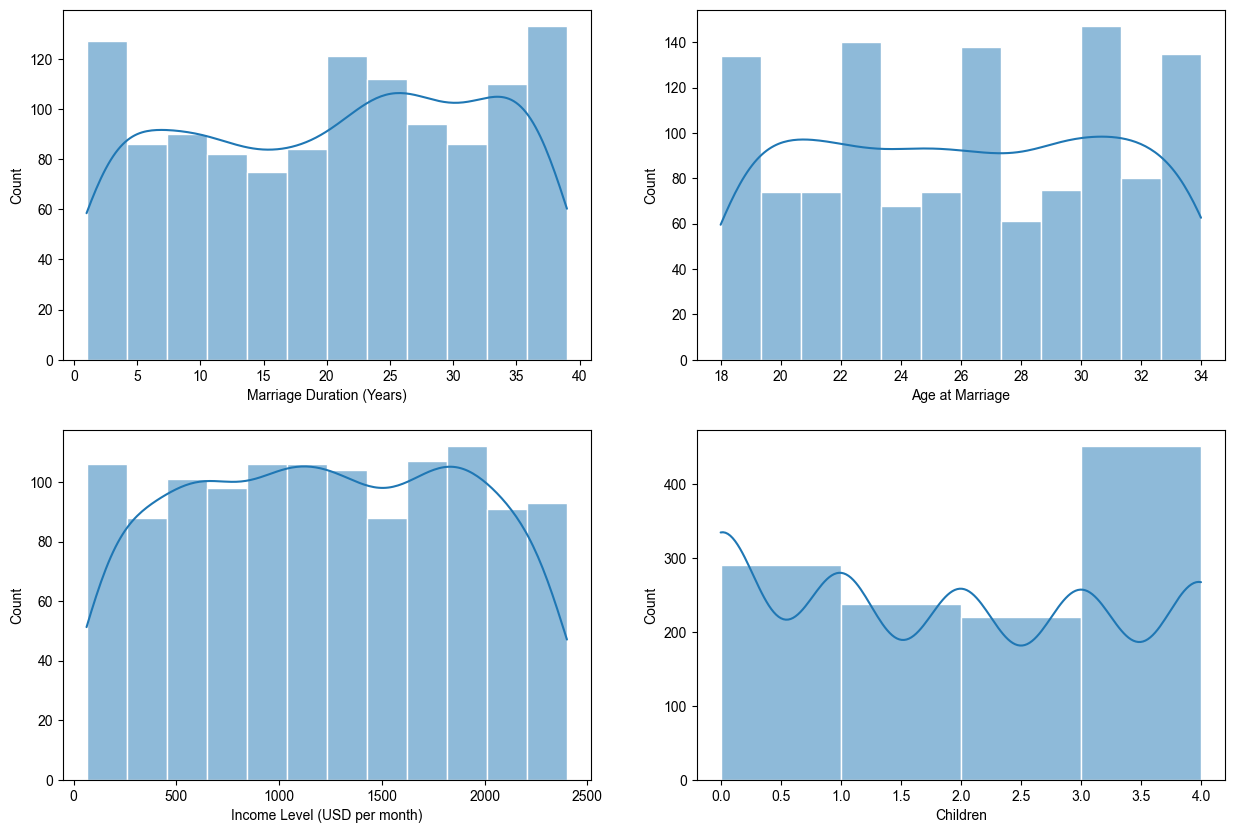

In [9]:
# Age at marriage and Marriage duration.
#COUNTING VALUES
data = df_quantitative_variables


fig, axs = plt.subplots( 2, 2,
    figsize=(15,10)
)

sns.set_theme(style="ticks")
sns.histplot(data, x="Marriage Duration (Years)", ax = axs[0,0], kde=True)

sns.histplot(data, x="Age at Marriage", ax = axs[0,1], kde=True)

sns.histplot(data, x="Income Level (USD per month)", ax = axs[1,0], kde=True)

sns.histplot(data, x="Children", ax = axs[1,1], kde=True, bins=4)

In [10]:
df_quantitative_variables

,Marriage Duration (Years),Age at Marriage,Income Level (USD per month),Children
0,39,29,1361.568,2
1,29,34,224.184,0
2,15,34,1913.460,4
3,8,27,757.920,1
4,21,34,343.992,1
...,...,...,...,...
1195,38,22,319.656,4
1196,34,21,72.876,2
1197,12,23,2190.996,3
1198,19,31,411.840,4


### Relationship Between Marriage Duration and Age at Marriage

Text(0.5, 1.0, 'Frecuency Marriage Duration - Age at Marriage')

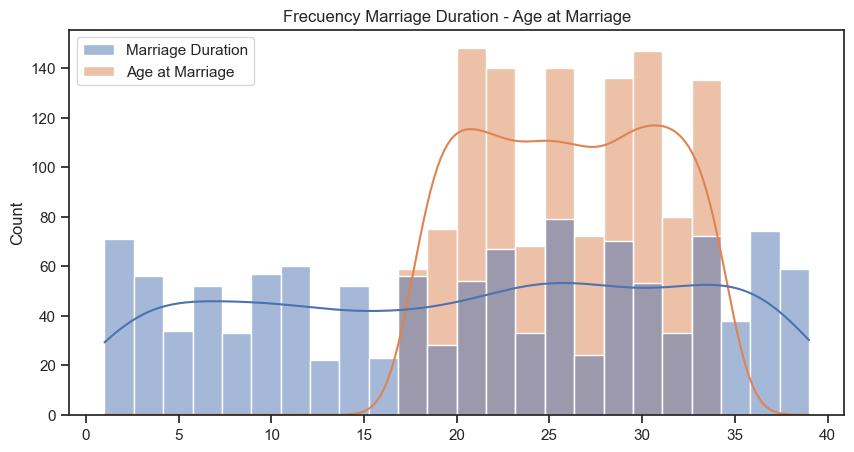

In [48]:
#Marriage Duration - Age at Marriage
data1 = {
    "Marriage Duration": df_quantitative_variables["Marriage Duration (Years)"],
    "Age at Marriage": df_quantitative_variables["Age at Marriage"]
}

data2 = {
    "Income Level": df_quantitative_variables["Income Level (USD per month)"].shape[0],
    "Children Quantity": df_quantitative_variables["Children"]
}

fig, axs = plt.subplots(
    figsize=(10,5)
)

sns.histplot(data1, kde=True)
plt.title("Frecuency Marriage Duration - Age at Marriage")




### Insight
- Relation between Age at Marriage and Marriage Duration
  -We can see significant variations in marriage duration among people who get married at an early age (before their 20s) and longer marriage durations for those who marry after their 20s.
  - Most people in this country get married between the ages of 20 and 34.
 
 People who get marriage at 20, 22 and 30, 32 years old, have the largest duration in their marriages. In the other hand we have the 


## Qualitative Variables
- Age at marriage - Family involvement.
- Caste/Religion - Marriage type.
- Family Involvement - Children.

In [12]:
df_qualitative_variables = df[["Marriage Type", "Education Level", "Caste/Religion", "Urban/Rural", "Family Involvement", "Divorce Status"]]
df_qualitative_variables

,Marriage Type,Education Level,Caste/Religion,Urban/Rural,Family Involvement,Divorce Status
0,Love,Secondary,Hindu,Rural,Moderate,No
1,Arranged,No Education,Jain,Rural,Moderate,Yes
2,Love,No Education,Muslim,Urban,Moderate,Yes
3,Arranged,Postgraduate,Jain,Urban,High,Yes
4,Love,Secondary,Jain,Urban,High,Yes
...,...,...,...,...,...,...
1195,Love,Primary,Muslim,Urban,High,No
1196,Arranged,Postgraduate,Hindu,Rural,Moderate,No
1197,Arranged,Postgraduate,Other,Rural,Moderate,Yes
1198,Arranged,Secondary,Christian,Rural,Moderate,No


### Filtering according to the amount of values 

Text(0, 0.5, 'Quantity')

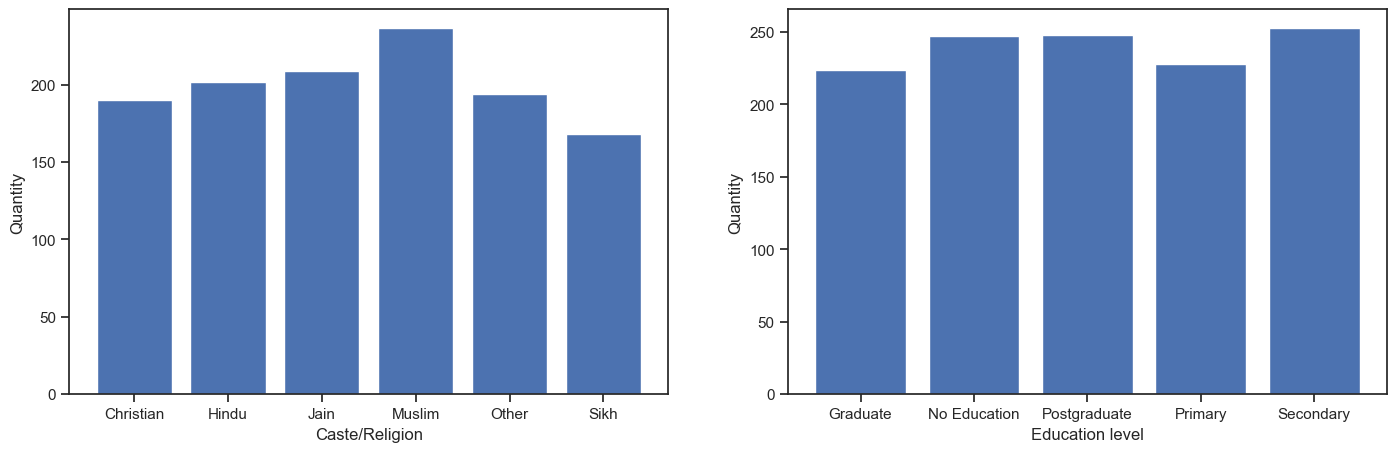

In [13]:
#Quantity acording Caste/religion

content_castel_religion = {
    "Christian": df_qualitative_variables[df_qualitative_variables["Caste/Religion"] == "Christian"].shape[0],
    "Hindu": df_qualitative_variables[df_qualitative_variables["Caste/Religion"] == "Hindu"].shape[0],
    "Jain": df_qualitative_variables[df_qualitative_variables["Caste/Religion"] == "Jain"].shape[0],
    "Muslim": df_qualitative_variables[df_qualitative_variables["Caste/Religion"] == "Muslim"].shape[0],
    "Other": df_qualitative_variables[df_qualitative_variables["Caste/Religion"] == "Other"].shape[0],
    "Sikh": df_qualitative_variables[df_qualitative_variables["Caste/Religion"] == "Sikh"].shape[0]
}
labels_castel = content_castel_religion.keys()
content_values_castel = content_castel_religion.values()


#Quantity according Education level
quantiti_variable_ED_Level = df_qualitative_variables["Education Level"].value_counts()
label_ED = quantiti_variable_ED_Level.index

content_education_level = {
    "Graduate": df_qualitative_variables[df_qualitative_variables["Education Level"] == "Graduate"].shape[0],
    "No Education": df_qualitative_variables[df_qualitative_variables["Education Level"] == "No Education"].shape[0],
    "Postgraduate": df_qualitative_variables[df_qualitative_variables["Education Level"] == "Postgraduate"].shape[0],
    "Primary": df_qualitative_variables[df_qualitative_variables["Education Level"] == "Primary"].shape[0],
    "Secondary": df_qualitative_variables[df_qualitative_variables["Education Level"] == "Secondary"].shape[0]
}

content_education_level_labels = content_education_level.keys()
content_education_level_values_count = content_education_level.values()

fig, axs = plt.subplots(
    figsize=(17,5), ncols=2
)

#Quantity acording Caste/religion
axs[0].bar(labels_castel, content_values_castel)
axs[0].set_ylabel("Quantity")
axs[0].set_xlabel("Caste/Religion")

#Quantity according Education level
axs[1].bar(content_education_level_labels, content_education_level_values_count)
axs[1].set_xlabel("Education level")
axs[1].set_ylabel("Quantity")


Text(0.5, 0, 'Divorce Status')

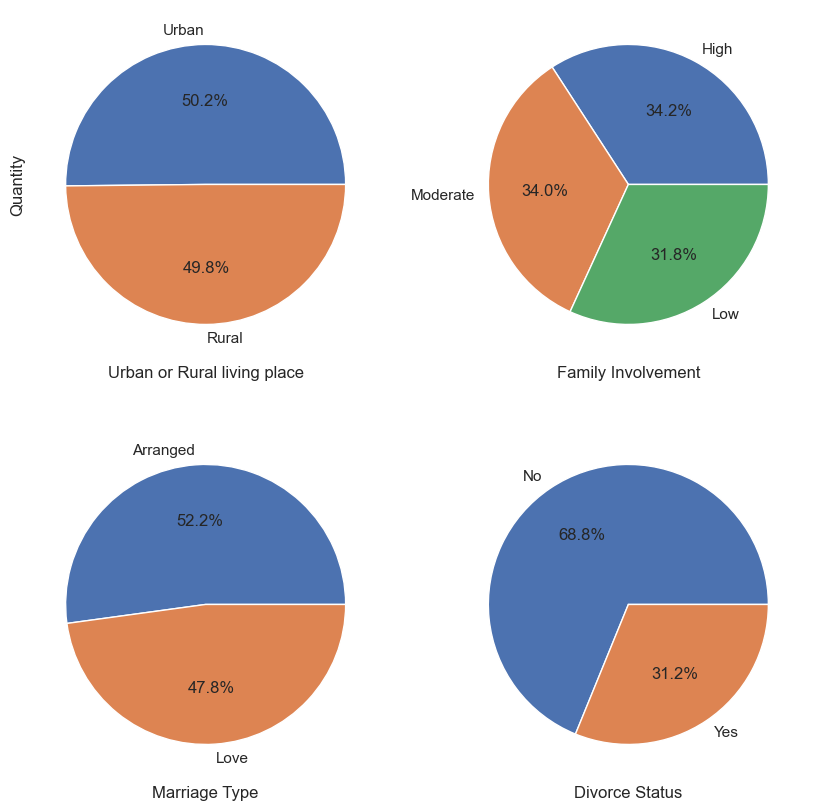

In [14]:
#Quantity according Urban/Rural
quantiti_urban_rural = df_qualitative_variables["Urban/Rural"].value_counts()
label_Uraban_rural = quantiti_urban_rural.index

#Quantity according Family involvement
Quantiti_Family_involvement = df_qualitative_variables["Family Involvement"].value_counts()
label_family_involvement = Quantiti_Family_involvement.index

#Quantity according Marriage type
quantiti_marriage_type = df_qualitative_variables["Marriage Type"].value_counts()
label_marriage_type = quantiti_marriage_type.index

#Quantity according Divorce status
quantiti_divorce_status = df_qualitative_variables["Divorce Status"].value_counts()
labe_divorce_status = quantiti_divorce_status.index
fig, axs = plt.subplots(2,2,
    figsize=(10,10)
)

#Quantity according Urban/Rural
axs[0,0].pie(quantiti_urban_rural, labels=label_Uraban_rural, autopct="%1.1f%%")
axs[0,0].set_xlabel("Urban or Rural living place")
axs[0,0].set_ylabel("Quantity")
#---------------------------------------

#Quantity according Family involvement
axs[0,1].pie(Quantiti_Family_involvement, labels=label_family_involvement, autopct="%1.1f%%")
axs[0,1].set_xlabel("Family Involvement")

#Quantity according Marriage type
axs[1,0].pie(quantiti_marriage_type, labels=label_marriage_type, autopct="%1.1f%%")
axs[1,0].set_xlabel("Marriage Type")

#Quantity according Divorce status
axs[1,1].pie(quantiti_divorce_status, labels=labe_divorce_status, autopct="%1.1f%%")
axs[1,1].set_xlabel("Divorce Status")

#### Relevant Insights
- Quantity related to the type of Caste/Religion:
We can see that the Muslim religion has the majority of marriages in this dataset.

- Family Involvement:
We can suppose that, due to the types of religions in this country, it’s normal to observe notable family involvement.

- Insights related to Divorce Status:
As we can see, most of the marriages did not lead to divorce.





1) Age at marriage and Marriage duration.
3) Age at marriage and Family Involvement.
3) Caste/Religion and Marriage Type.
4) Family Involvement and Children.
5) Urban/Rural and Children.

In [50]:
df

,Unique ID,Marriage Duration (Years),Age at Marriage,Marriage Type,Education Level,Income Level (USD per month),Caste/Religion,Urban/Rural,Family Involvement,Children,Divorce Status
0,MD1,39,29,Love,Secondary,1361.568,Hindu,Rural,Moderate,2,No
1,MD2,29,34,Arranged,No Education,224.184,Jain,Rural,Moderate,0,Yes
2,MD3,15,34,Love,No Education,1913.460,Muslim,Urban,Moderate,4,Yes
3,MD4,8,27,Arranged,Postgraduate,757.920,Jain,Urban,High,1,Yes
4,MD5,21,34,Love,Secondary,343.992,Jain,Urban,High,1,Yes
...,...,...,...,...,...,...,...,...,...,...,...
1195,MD1196,38,22,Love,Primary,319.656,Muslim,Urban,High,4,No
1196,MD1197,34,21,Arranged,Postgraduate,72.876,Hindu,Rural,Moderate,2,No
1197,MD1198,12,23,Arranged,Postgraduate,2190.996,Other,Rural,Moderate,3,Yes
1198,MD1199,19,31,Arranged,Secondary,411.840,Christian,Rural,Moderate,4,No


In [76]:
#This pivot table groups the following variables: Caste/Religion, Marriage Type, and the children quantity in relation to these aspects
table_pivot_2 = df.pivot_table(index="Marriage Type", columns="Caste/Religion", values="Children", aggfunc="sum")
table_pivot_2

Caste/Religion,Christian,Hindu,Jain,Muslim,Other,Sikh
Marriage Type,,,,,,
Arranged,163,191,204,255,173,184
Love,184,203,187,220,146,153


<Axes: xlabel='Caste/Religion', ylabel='Marriage Type'>

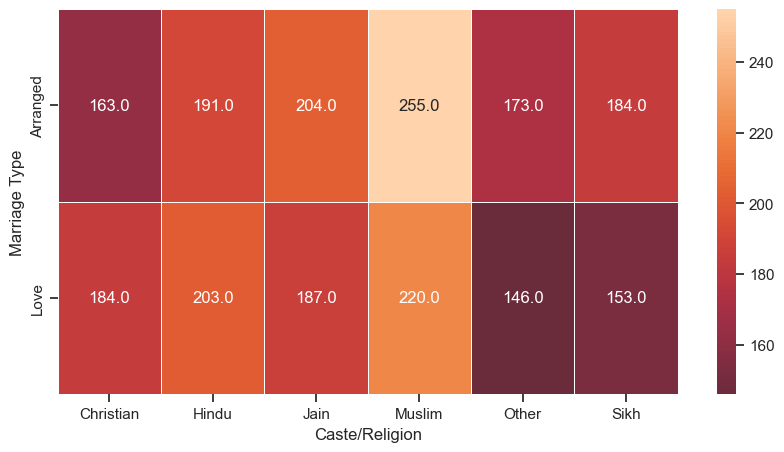

In [74]:
fig, ax = plt.subplots(
    figsize=(10,5)
)
sns.heatmap(table_pivot_2, center=100, annot=True, fmt=".1f", linewidths=0.5)

#### Insights
- In the Mulim religion we can see more children with arranged marriages than the others castes or religions. 

In [53]:
#This pivot table groups the following variables: Caste/Religion, Age at Marriage, and the duration for each age in relation to the type of caste or religion
tabla_pivot = df.pivot_table(index="Age at Marriage", columns="Caste/Religion", values="Marriage Duration (Years)", aggfunc="sum")
tabla_pivot

Caste/Religion,Christian,Hindu,Jain,Muslim,Other,Sikh
Age at Marriage,,,,,,
18,217,213,210,228,156,36
19,215,227,217,253,274,295
20,217,199,259,181,327,306
21,415,180,247,440,233,215
22,334,207,140,220,280,271
23,195,198,234,252,247,261
24,241,319,205,209,246,208
25,378,233,192,336,191,180
26,266,242,192,322,209,243


<Axes: xlabel='Caste/Religion', ylabel='Age at Marriage'>

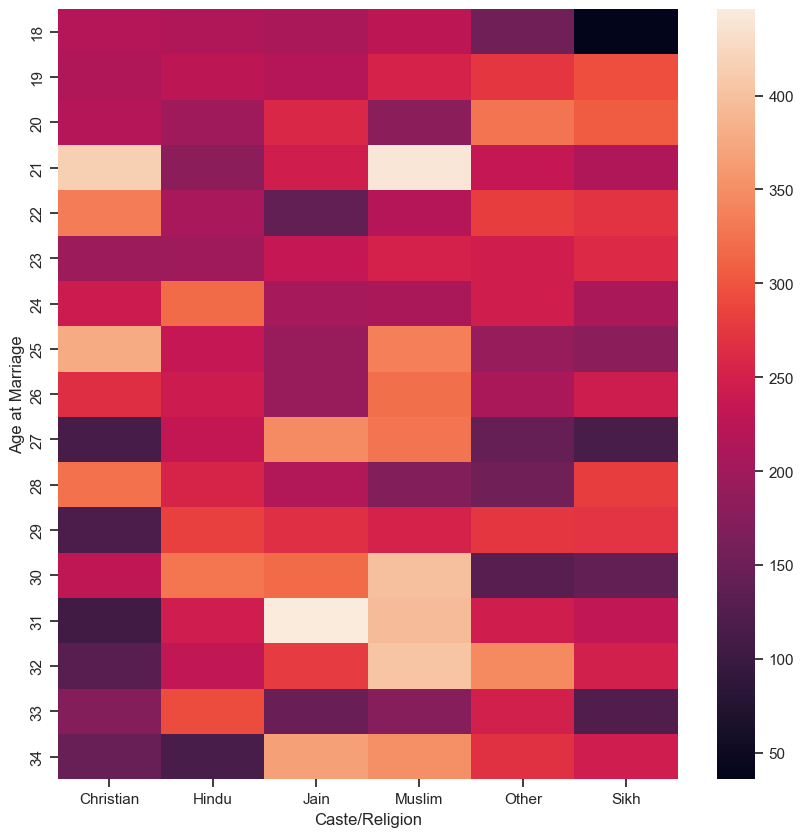

In [56]:
fig, ax = plt.subplots(
    figsize=(10,10)
)
sns.heatmap(tabla_pivot)

# Column Filtering by